# GQKAE on H₄, from scratch

Here's the whole thing in one sentence: **we train a tiny GPT whose vocabulary is quantum gates, and we reward it when the circuit it writes has low energy.** That's it. Everything else is details.

The paper is [arXiv:2605.04604](https://arxiv.org/abs/2605.04604). They run six molecules on an H200. We run one (H₄, 8 qubits) on a laptop or a Sol node, and we check every number against the exact answer, because at 8 qubits we can.

We compare four ways to get the ground-state energy:

- **HF, CCSD, CASCI**: classical chemistry. CASCI is the exact answer, i.e. our label.
- **VQE**: the classic quantum approach. Fixed circuit, tune the knobs.
- **GQE**: a tiny GPT picks the gates, trained with RL.
- **GQKAE**: same as GQE, but the MLP inside each transformer block is swapped for a slimmer KAN-style block (HQKAN).


## 1. Chemistry for CS people

You already know Hamiltonians. The only chemistry you need here is two things: *where the Hamiltonian comes from*, and *what the bits mean*.

**The molecule.** Four hydrogen atoms in a line, spaced \(R\) Å apart. Four electrons total. For each \(R\) we want the lowest energy \(E_0(R)\). Plot \(E_0\) against \(R\) and you get a *potential energy surface* (PES), which is basically "how much does it cost to stretch the chain".

**Orbitals are slots.** Electrons live in orbitals. Think of an orbital as a slot that holds at most 2 electrons: one spin-up (\(\alpha\)) and one spin-down (\(\beta\)). That's Pauli exclusion. The 6-31G basis gives us 8 orbitals, but most barely matter, so we keep the 4 around the "frontier" (the HOMO–LUMO gap). That's the **active space (4e, 4o)**: 4 electrons, 4 orbitals, ×2 spins = **8 spin-orbitals = 8 qubits**.

**A bitstring is a configuration.** One qubit per spin-orbital: 1 = occupied, 0 = empty. Wires go \(\alpha_0\beta_0\alpha_1\beta_1\alpha_2\beta_2\alpha_3\beta_3\), so `11110000` means "the two lowest orbitals are full". Chemists call one of these bitstrings a **Slater determinant**. (It's a determinant because electrons are fermions: the wavefunction flips sign when you swap two of them. The Jordan–Wigner mapping does that sign bookkeeping for you.) Valid bitstrings have exactly 2 \(\alpha\) and 2 \(\beta\), which gives \(\binom{4}{2}^2 = 36\). So the true ground state is a vector in a 36-dim space. Tiny!

**Hartree–Fock = the best single bitstring.** HF says: the ground state is just `11110000`, with the orbital shapes optimized. It's a mean-field approximation. Near equilibrium that's decent (about 28 mHa off at \(R = 1\) Å). Now stretch the chain. The atoms stop sharing electrons nicely, and the true ground state becomes a genuine superposition of many bitstrings. HF physically can't represent that, so it blows up (about 200 mHa off at 2.2 Å). That failure is the whole point of Fig. 4(a).

**CASCI = the label.** Build the 36×36 Hamiltonian matrix in the bitstring basis and diagonalize it. Exact. That's our ground truth. "Chemical accuracy" means landing within **1.6 mHa** of it, about 1 kcal/mol, which is roughly the precision chemists care about.

**CCSD** is a classical approximation that starts from HF and adds corrections. It's great when HF is close. When HF is far off it wobbles, and at stretched geometries it can even dip *below* the exact answer, because it isn't variational.

Honest note: H₄ is small enough that CASCI takes microseconds. Nobody needs a quantum computer for this molecule. It's a testbed, and the reason to use it is that we can check every single number.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src" / "gqkae").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from gqkae.molecule import H4System, reference_energies
from gqkae.operators import hf_occupation

print("6-31G MOs vs 8-qubit active space")
for R in (1.0, 2.0):
    mol = H4System(bond_length=R)
    nmo = mol.mf.mo_coeff.shape[1]
    gap = 1e3 * (mol.hf_energy - mol.casci_energy())
    print(
        f"R={R:.1f} Å  n_AO/MO={nmo}  active={mol.norb}o/{mol.n_qubits}q  "
        f"HF={mol.hf_energy:.6f}  CASCI={mol.casci_energy():.6f}  "
        f"HF−CASCI={gap:.1f} mHa  HF bits={''.join(map(str, hf_occupation(mol)))}"
    )
print("\nHF−CASCI grows as the chain stretches: mean-field cannot describe dissociation.")

6-31G MOs vs 8-qubit active space
R=1.0 Å  n_AO/MO=8  active=4o/8q  HF=-2.160244  CASCI=-2.188674  HF−CASCI=28.4 mHa  HF bits=11110000
R=2.0 Å  n_AO/MO=8  active=4o/8q  HF=-1.838039  CASCI=-2.004579  HF−CASCI=166.5 mHa  HF bits=11110000

HF−CASCI grows as the chain stretches: mean-field cannot describe dissociation.


## 2. The problem, stated like an ML problem

Input: a Hamiltonian \(\hat H(R)\), a 256×256 Hermitian matrix on 8 qubits. Output: its smallest eigenvalue.

\[
E_0(R) = \min_{\lvert\psi\rangle} \langle\psi\lvert \hat H(R)\rvert\psi\rangle.
\]

At 8 qubits you can just call `eigh`, and we do (that's CASCI). The algorithms below pretend you can't. That's the real situation at 50+ qubits, where the matrix has more entries than there are atoms in your laptop.


In [2]:
sys0 = H4System(bond_length=1.0)
print(f"qubits={sys0.n_qubits}, nelec={sys0.nelec}, norb={sys0.norb}")
print(f"HF    = {sys0.hf_energy:.8f} Ha")
print(f"CASCI = {sys0.casci_energy():.8f} Ha")
print(f"gap   = {1e3*(sys0.hf_energy - sys0.casci_energy()):.2f} mHa")


qubits=8, nelec=(2, 2), norb=4
HF    = -2.16024391 Ha
CASCI = -2.18867380 Ha
gap   = 28.43 mHa


## 3. Three ways to search for the ground state

### VQE: fixed circuit, turn the knobs

Take the UCCSD circuit: 26 excitation gates (8 singles, 18 doubles), each with its own angle \(\theta\). Start at \(\boldsymbol\theta = 0\), which is exactly HF. Hand \(\langle H\rangle(\boldsymbol\theta)\) to a classical optimizer (COBYLA) and let it twist the knobs until the energy stops dropping. Every learnable parameter lives *on the quantum circuit*. That's the problem at scale: signals through the circuit are noisy, and gradients can vanish (barren plateaus).

### GQE: a GPT that writes circuits

Flip it around. Freeze every gate angle at \(\pi/2\). Now the only choices are *which* gates and *in what order*. That's a sequence, and we have a very good hammer for sequences.

- vocabulary = 27 tokens (identity + the 26 excitation gates)
- a sentence = 20 tokens = a circuit applied to `11110000`:  \(\lvert\psi(\boldsymbol j)\rangle = \hat U_{j_{20}}\cdots\hat U_{j_1}\lvert\mathrm{HF}\rangle\)
- model = a small decoder-only transformer:  \(\pi_\theta(\boldsymbol j)=\prod_t \pi_\theta(j_t\mid j_{<t})\)

Now every learnable parameter lives in the classical model. The quantum computer just runs circuits and hands back samples.

### GQKAE: swap the MLP

Each transformer block has a feed-forward MLP, \(W_2\,\mathrm{GELU}(W_1 h)\). It's usually the fattest part of the model. GQKAE replaces it with **HQKAN**: squeeze \(h\) down to 12 dims, push each dim through learnable 1-D functions, and project back up. The 1-D functions are **DARUAN**: a simulated single-qubit circuit that re-uploads its input a few times, which works out to a small learnable Fourier series. Same job, fewer parameters. Here that's 15.7k vs 27.3k (about 43% fewer); the paper gets about 66% fewer at GPT-2 scale.

DARUAN is "quantum-*inspired*": it's ordinary JAX math that happens to look like a qubit. It never runs on the quantum device.

### The reward: QSCI

How do you score a circuit? Don't estimate \(\langle H\rangle\) directly (that's expensive and noisy). Instead:

1. Run the circuit and measure the 8 bits, \(N\) times. You get a histogram of bitstrings.
2. Keep the valid ones (2\(\alpha\) + 2\(\beta\)). These are your candidate "important configurations".
3. Restrict \(H\) to those bitstrings and diagonalize. The matrix is tiny, so this is cheap.
4. \(E_{\mathrm{QSCI}}\) = lowest eigenvalue, reward \(r = -E_{\mathrm{QSCI}}\).

\[
E_{\mathrm{QSCI}}(\boldsymbol{j})=\min_{\lvert\phi\rangle\in\mathcal{S}(\boldsymbol j)}\langle\phi\lvert\hat H\rvert\phi\rangle
\]

So the circuit's job is to *propose* the right bitstrings, and linear algebra does the rest. Nice property: \(E_{\mathrm{QSCI}} \ge E_{\mathrm{CASCI}}\) always (it's a variational bound), with equality once every important bitstring shows up.

### The training: GRPO

Sample a group of \(M\) circuits and score each one. Advantage = \((r - \bar r)/\sigma_r\) within the group, so "better than your siblings" gets pushed up and "worse" gets pushed down. Then take a PPO-style clipped step on the token log-probs, with ratio \(\rho_t = \pi_\theta/\pi_{\theta_{\text{old}}}\) and clip \(\epsilon = 0.2\). No value network. It's the same trick people use to RL-finetune LLMs on math problems; here the "math problem" is a molecule.


### Aside: making it fast (Catalyst + Lightning)

Every training step runs dozens of circuits, so circuit speed matters. Two pieces:

- **`lightning.qubit`**: PennyLane's C++ statevector simulator. Same answers as `default.qubit`, much faster.
- **Catalyst `@qjit`** ([docs](https://docs.pennylane.ai/projects/catalyst/en/stable/)): compiles the whole quantum function, through MLIR and LLVM, into one native program.

The catch: the model samples a *different* circuit every time, and naively you'd recompile for each one, which defeats the purpose. The trick is to make the token sequence an **input** to the compiled program. At each of the 20 steps, apply *all* 26 gates, but set each gate's angle to 0 unless it's the chosen token. A rotation by 0 does nothing, so the circuit is exactly right. We compile once (a few seconds) and after that each circuit takes a few milliseconds.

Shots: we compute the exact probabilities and draw \(N\) shots from them with a multinomial. That has the same statistics as measuring \(N\) times.

Same idea on the classical side: sampling 20 tokens from the transformer happens inside a single `jax.jit`. Together, these two changes took one GQKAE training run from about 35 s to about 3 s.

In [3]:
import time
from gqkae.circuit import statevector_probs
from gqkae.operators import build_uccsd_pool

pool = build_uccsd_pool(sys0)
rng = np.random.default_rng(0)

t0 = time.perf_counter()
statevector_probs(sys0, pool, rng.integers(0, len(pool), size=20))
print(f"first call (compiles): {time.perf_counter() - t0:.2f} s")

t0 = time.perf_counter()
for _ in range(100):
    statevector_probs(sys0, pool, rng.integers(0, len(pool), size=20))
print(f"100 new random circuits: {time.perf_counter() - t0:.2f} s  (no recompiles)")

first call (compiles): 0.67 s


100 new random circuits: 0.70 s  (no recompiles)


## 4. Sanity check: recover the answers we already know

Before training anything: an empty circuit leaves the state at `11110000`, so QSCI must return *exactly* HF. (The mirror check, hand QSCI all 36 valid bitstrings and it must return exactly CASCI, lives in `tests/test_h4.py`.) If either fails, nothing downstream means anything.


In [4]:
from gqkae.operators import build_uccsd_pool, hf_occupation
from gqkae.qsci import build_full_cas_hamiltonian, evaluate_sequence

pool = build_uccsd_pool(sys0)
print(f"vocab size = {len(pool)}  (identity + UCCSD singles/doubles)")
print("HF bitstring:", "".join(map(str, hf_occupation(sys0))))

H_full, na, nb = build_full_cas_hamiltonian(sys0.hamiltonian)
res = evaluate_sequence(sys0, pool, token_ids=[], shots=2048, seed=0, H_full=H_full, na=na, nb=nb)
print(f"HF-circuit QSCI ≈ {res.energy:.8f} Ha  (subspace dim {res.subspace_dim})")
print(f"CASCI            = {sys0.casci_energy():.8f} Ha")


vocab size = 27  (identity + UCCSD singles/doubles)
HF bitstring: 11110000


HF-circuit QSCI ≈ -2.16024391 Ha  (subspace dim 1)
CASCI            = -2.18867380 Ha


## 5. Train all three at R = 1.0 Å

Tiny budget, just to watch it work: 8 iterations, 4 circuits per iteration, 512 shots. (The paper uses 100 iterations, 10 circuits, 100k shots. For the real run: `gqkae-h4 compare --profile nano`.)

What to expect: H₄ is easy. The paper says both GQE and GQKAE hit chemical accuracy almost immediately and the error curves are flat. If yours aren't, something is broken.


In [5]:
from gqkae.train import TrainConfig, train_geometry
from gqkae.vqe import run_vqe

def mini_train(backbone: str):
    cfg = TrainConfig(
        bond_length=1.0,
        n_iters=8,
        group_size=4,
        seq_len=20,
        shots=512,
        seed=0,
        backbone=backbone,
        out_dir=str(ROOT / "runs" / f"notebook_{backbone}_R1"),
    )
    return train_geometry(cfg)

gqkae = mini_train("gqkae")
gqe = mini_train("gqe")
vqe = run_vqe(sys0, maxiter=120)

print(f"CASCI  = {sys0.casci_energy():.8f} Ha")
print(f"HF     = {sys0.hf_energy:.8f} Ha")
print(f"VQE    = {vqe.energy:.8f} Ha  err={1e3*(vqe.energy-sys0.casci_energy()):.3f} mHa  evals={vqe.n_evals}")
print(f"GQE    = {gqe.best_energy:.8f} Ha  err={1e3*(gqe.best_energy-gqe.casci_energy):.3f} mHa  params={gqe.n_params}")
print(f"GQKAE  = {gqkae.best_energy:.8f} Ha  err={1e3*(gqkae.best_energy-gqkae.casci_energy):.3f} mHa  params={gqkae.n_params}")



H4 gqkae R=1.00:   0%|          | 0/8 [00:00<?, ?it/s]


H4 gqkae R=1.00:  12%|█▎        | 1/8 [00:01<00:10,  1.48s/it]


H4 gqkae R=1.00:  38%|███▊      | 3/8 [00:01<00:02,  2.32it/s]


H4 gqkae R=1.00:  62%|██████▎   | 5/8 [00:01<00:00,  4.13it/s]


H4 gqkae R=1.00:  88%|████████▊ | 7/8 [00:01<00:00,  6.00it/s]

...


H4 gqe R=1.00:  12%|█▎        | 1/8 [00:00<00:05,  1.31it/s]


H4 gqe R=1.00:  50%|█████     | 4/8 [00:00<00:00,  5.63it/s]


H4 gqe R=1.00:  88%|████████▊ | 7/8 [00:01<00:00,  9.54it/s]


H4 gqe R=1.00: 100%|██████████| 8/8 [00:01<00:00,  7.59it/s]

CASCI  = -2.18867380 Ha
HF     = -2.16024391 Ha
VQE    = -2.18752223 Ha  err=1.152 mHa  evals=120
GQE    = -2.18867380 Ha  err=0.000 mHa  params=27323
GQKAE  = -2.18867380 Ha  err=0.000 mHa  params=15699


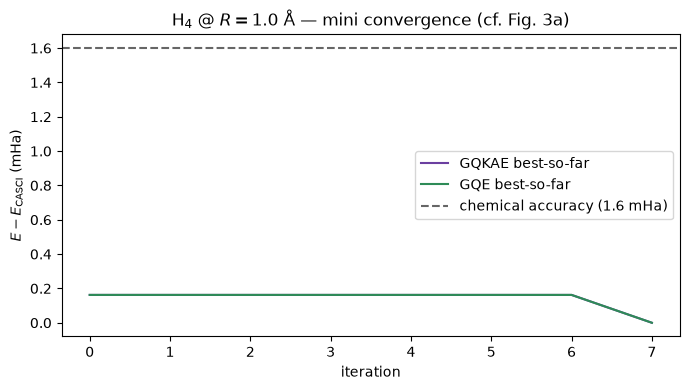

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for name, res, color in (("GQKAE", gqkae, "#6b3fa0"), ("GQE", gqe, "#2e8b57")):
    hist = res.history
    iters = [h["iter"] for h in hist]
    best = np.array([h["best_so_far"] for h in hist])
    ax.plot(iters, 1e3 * (best - res.casci_energy), color=color, label=f"{name} best-so-far")
ax.axhline(1.6, color="0.4", ls="--", label="chemical accuracy (1.6 mHa)")
ax.set_xlabel("iteration")
ax.set_ylabel(r"$E - E_{\mathrm{CASCI}}$ (mHa)")
ax.set_title(r"H$_4$ @ $R=1.0$ Å — mini convergence (cf. Fig. 3a)")
ax.legend()
fig.tight_layout()
plt.show()


## 6. The full curve (Fig. 4(a) and 5(a))

This loads the output of `gqkae-h4 compare` (it looks in `runs/h4_nano`, then `h4_laptop`, then `h4_smoke`) and plots energy vs \(R\), plus |error| vs \(R\) on a log scale with the 1.6 mHa line. If there's no run on disk yet, it does a tiny GQKAE-only scan instead.

How to read it: HF's error explodes as \(R\) grows, because the single-bitstring picture breaks. GQE and GQKAE should stay under the dashed line everywhere, since they never assumed one bitstring. (In the nano run they match CASCI to machine precision, so they sit on the 1e-6 plotting floor and GQE hides behind GQKAE.)

**Now the important caveat.** Don't read "GQE/GQKAE are exact" as "the model is smart". Try the dumbest possible baseline, *random* 20-token circuits, with 8192 shots: 30–40% of them already hit chemical accuracy, because the space has only 36 bitstrings and the shots find most of them. Training looks at about 560 circuits and reports the best, so it basically can't miss. In the nano logs, every seed of both models is under 1.6 mHa at iteration 0. The paper sees the same thing ("nearly flat error curves ... from the very first iterations").

The policy does learn a little: the *average* circuit's error drops from about 18 mHa to about 11–13 mHa over training. But H₄ can't tell GQE and GQKAE apart. It's a correctness check, not a benchmark. The paper's interesting results (N₂, LiH) are the molecules where random circuits don't get lucky.


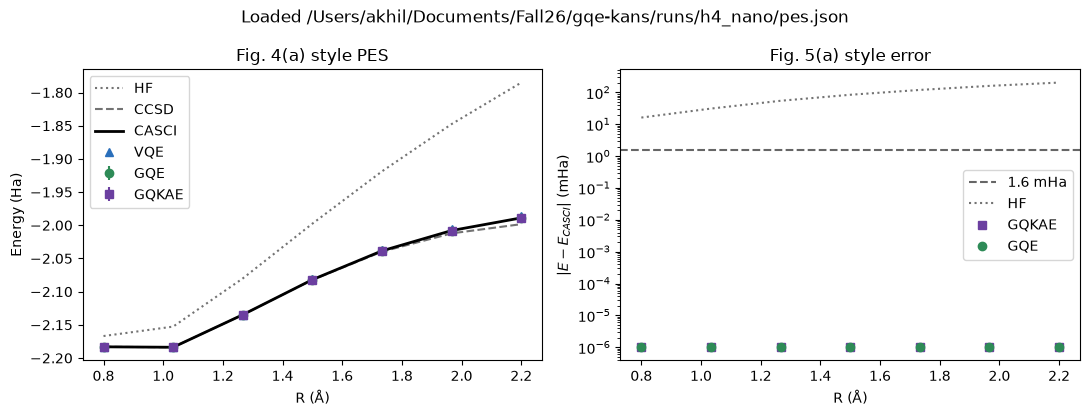

In [7]:
import json
from pathlib import Path

COMPARE_DIRS = [
    ROOT / "runs" / "h4_nano",
    ROOT / "runs" / "h4_laptop",
    ROOT / "runs" / "h4_smoke",
]
pes_path = next((p / "pes.json" for p in COMPARE_DIRS if (p / "pes.json").exists()), None)
RUN_MINI_PES = pes_path is None  # set True to force a short GQKAE-only scan

if pes_path is not None and not RUN_MINI_PES:
    data = json.loads(pes_path.read_text())
    Rs = np.array(data["R"])
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    ax = axes[0]
    ax.plot(Rs, data["HF"], ":", color="0.45", label="HF")
    ax.plot(Rs, data["CCSD"], "--", color="0.45", label="CCSD")
    ax.plot(Rs, data["CASCI"], "-", color="k", lw=2, label="CASCI")
    if np.isfinite(data["VQE"]).any():
        ax.plot(Rs, data["VQE"], "^", color="#2a6fbb", label="VQE")
    if np.isfinite(data["GQE_mean"]).any():
        ax.errorbar(Rs, data["GQE_mean"], yerr=data["GQE_std"], fmt="o", color="#2e8b57", label="GQE")
    if np.isfinite(data["GQKAE_mean"]).any():
        ax.errorbar(Rs, data["GQKAE_mean"], yerr=data["GQKAE_std"], fmt="s", color="#6b3fa0", label="GQKAE")
    ax.set_xlabel("R (Å)"); ax.set_ylabel("Energy (Ha)"); ax.set_title("Fig. 4(a) style PES")
    ax.legend()
    ax = axes[1]
    casci = np.array(data["CASCI"])
    ax.axhline(1.6, color="0.4", ls="--", label="1.6 mHa")
    ax.semilogy(Rs, np.abs(np.array(data["HF"]) - casci) * 1e3, ":", color="0.45", label="HF")
    if np.isfinite(data["GQKAE_mean"]).any():
        ax.semilogy(Rs, np.clip(np.abs(np.array(data["GQKAE_mean"]) - casci) * 1e3, 1e-6, None), "s", color="#6b3fa0", label="GQKAE")
    if np.isfinite(data["GQE_mean"]).any():
        ax.semilogy(Rs, np.clip(np.abs(np.array(data["GQE_mean"]) - casci) * 1e3, 1e-6, None), "o", color="#2e8b57", label="GQE")
    ax.set_xlabel("R (Å)"); ax.set_ylabel(r"$|E-E_{CASCI}|$ (mHa)"); ax.set_title("Fig. 5(a) style error")
    ax.legend()
    fig.suptitle(f"Loaded {pes_path}")
    fig.tight_layout()
    plt.show()
else:
    Rs = np.linspace(0.9, 2.0, 3)
    refs = reference_energies(Rs)
    gqkae_E = []
    for i, R in enumerate(Rs):
        cfg = TrainConfig(
            bond_length=float(R), n_iters=6, group_size=4, seq_len=20, shots=256,
            seed=10 + i, backbone="gqkae",
            out_dir=str(ROOT / "runs" / "notebook_pes" / f"R_{R:.3f}"),
        )
        r = train_geometry(cfg)
        gqkae_E.append(r.best_energy)
        print(f"R={R:.3f}  GQKAE={r.best_energy:.6f}  CASCI={r.casci_energy:.6f}  Δ={1e3*(r.best_energy-r.casci_energy):.2f} mHa")
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.plot(Rs, refs["HF"], ":", color="0.45", label="HF")
    ax.plot(Rs, refs["CCSD"], "--", color="0.45", label="CCSD")
    ax.plot(Rs, refs["CASCI"], "-", color="k", lw=2, label="CASCI")
    ax.plot(Rs, gqkae_E, "s", ms=8, color="#6b3fa0", label="GQKAE")
    ax.set_xlabel("Bond length R (Å)")
    ax.set_ylabel("Energy (Ha)")
    ax.set_title(r"H$_4$ mini PES")
    ax.legend()
    fig.tight_layout()
    plt.show()


## 7. TLDR

- **The chemistry:** 4 electrons, 8 slots, 36 valid bitstrings. HF bets on one bitstring and loses when you stretch the bonds. CASCI diagonalizes the 36×36 matrix and is the ground truth.
- **The methods:** VQE tunes angles on a fixed circuit. GQE trains a tiny GPT, with RL, to write circuits. GQKAE is GQE with a slimmer MLP.
- **The reward:** QSCI. The circuit proposes bitstrings and `eigh` does the rest.
- **What the H₄ result means:** GQE and GQKAE match CASCI at every \(R\), but 30–40% of random circuits already do at 8192 shots. It shows the pipeline is correct. It doesn't show the model is smart.
- **How we know it's right:** empty circuit → HF, all 36 bitstrings → CASCI, compiled circuit = `default.qubit` circuit, UCCSD at \(\theta = 0\) → HF. All in `tests/test_h4.py`.
- **What we didn't reproduce:** GPT-2 scale, 100k shots, CUDA-Q, and the paper's wall-clock numbers. On Sol: `sbatch examples/sol_h4_nano.slurm`.
